# Bandit benchmark notebook

Этот ноутбук запускает benchmark-пайплайн (аналогично `src/run_benchmark.py`) на вашем датасете.

## 1) Настройки

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import polars as pl

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from run_benchmark import load_dataset
from bandit_benchmark import (
    CatBoostPolicy,
    LogisticTSLibPolicy,
    LaplaceThompsonViaBayesianLogRegPolicy,
    PartitionedTSLibPolicy,
    RandomPolicy,
    EpsilonGreedyPolicy,
    UCBPolicy,
    ThompsonSamplingPolicy,
    build_expected_reward_estimator,
    core_scenarios,
    default_five_scenarios,
    make_simulated_environment,
    preprocess_bandit_dataframe,
    run_scenarios,
    split_train_test_by_date,
)
from prepare_datasets import stage1_make_splits, stage2_scale_features


In [2]:
# Укажите путь к данным (.tsv или .parquet)
DATA_PATH = ROOT / 'data' / 'events.tsv'
PREPARED_TRAIN_PATH = ROOT / 'artifacts' / 'datasets' / 'train_prepared.parquet'
PREPARED_TEST_PATH = ROOT / 'artifacts' / 'datasets' / 'test_prepared.parquet'
USE_PREPARED_SPLITS = True
TEST_RATIO = 0.5
EPSILON = 0.1
SEED = 42
SIMULATE = False
STOCHASTIC_SIM = True
FULL_SCENARIOS = False


## 2) Загрузка и препроцессинг

In [3]:
if USE_PREPARED_SPLITS and PREPARED_TRAIN_PATH.exists() and PREPARED_TEST_PATH.exists():
    train_df = pl.read_parquet(PREPARED_TRAIN_PATH)
    test_df = pl.read_parquet(PREPARED_TEST_PATH)
    print('loaded prepared splits')
else:
    # Stage 1: load -> split -> filter -> save
    train_s1, test_s1 = stage1_make_splits(str(DATA_PATH), str(ROOT / 'artifacts' / 'datasets'), TEST_RATIO, SEED)
    # Stage 2: scale features and save prepared datasets
    train_final, test_final = stage2_scale_features(train_s1, test_s1, str(ROOT / 'artifacts' / 'datasets'))
    train_df = pl.read_parquet(train_final)
    test_df = pl.read_parquet(test_final)

print('train:', train_df.height, 'test(random only):', test_df.height)


loaded prepared splits
train: 12701839 test(random only): 3925311


## 3) Конфиг политик и сценариев

In [7]:
policy_factories = {
    'random': lambda: RandomPolicy(seed=SEED),
    'epsilon_greedy': lambda: EpsilonGreedyPolicy(epsilon=EPSILON, seed=SEED),
    'ucb': lambda: UCBPolicy(),
    'thompson_sampling': lambda: ThompsonSamplingPolicy(seed=SEED),
}

try:
    import scipy  # noqa: F401
    policy_factories['laplace_ts_logreg'] = lambda: LaplaceThompsonViaBayesianLogRegPolicy(seed=SEED)
except Exception:
    print('scipy is unavailable: skipping LaplaceThompsonViaBayesianLogRegPolicy')

try:
    import catboost  # noqa: F401
    policy_factories['catboost'] = lambda: CatBoostPolicy(random_seed=SEED)
except Exception:
    print('catboost is unavailable: skipping CatBoostPolicy')

# try:
#     import contextualbandits  # noqa: F401
#     policy_factories['logistic_ts'] = lambda: LogisticTSLibPolicy(random_seed=SEED)
#     policy_factories['partitioned_ts'] = lambda: PartitionedTSLibPolicy(random_seed=SEED)
# except Exception:
#     print('contextualbandits is unavailable: skipping LogisticTS/PartitionedTS')

scenarios = default_five_scenarios() if FULL_SCENARIOS else core_scenarios()

## 4) Запуск benchmark

In [12]:
train_df2 = train_df.sample(fraction=0.1, shuffle=True).sort("date")
test_df2 = test_df.sample(fraction=0.1, shuffle=True).sort("date")

In [13]:
env_reward = None
if SIMULATE:
    expected_fn = build_expected_reward_estimator(train_df)
    env_reward = make_simulated_environment(
        proba_predictor=expected_fn,
        stochastic=STOCHASTIC_SIM,
        seed=SEED,
    )

result = run_scenarios(
    train_df=train_df2,
    test_df=test_df2,
    policy_factories=policy_factories,
    scenarios=scenarios,
    env_reward=env_reward,
    show_progress=True,
)

metrics_df = result['metrics']
history_df = result['history']
action_stats_df = result['action_stats']
action_daily_stats_df = result['action_daily_stats']

display(metrics_df)
print('history rows:', len(history_df))
if SIMULATE:
    display(action_stats_df)
    display(action_daily_stats_df)


case_2_random_pretrain_online_update/random:   0%| 

case_2_random_pretrain_online_update/random: train_unique_actions=50


case_2_random_pretrain_online_update/epsilon_greedy

case_2_random_pretrain_online_update/epsilon_greedy: train_unique_actions=50


case_2_random_pretrain_online_update/ucb:   0%| | 0

...

case_2_random_pretrain_online_update/laplace_ts_logreg: train_unique_actions=50


case_2_random_pretrain_online_update/catboost:   0%

case_2_random_pretrain_online_update/catboost: train_unique_actions=50


,impressions_total,impressions_used,total_reward,ctr,ips_weighted_reward,ips_ctr,replay_match_rate,cumulative_regret,avg_regret,cumulative_ips_regret,avg_ips_regret,scenario,algo
0,392531,276585,4669.0,0.016881,6683.0,0.017025,0.704620,1101.186857,0.003981,5114.710194,0.013030,case_2_random_pretrain_online_update,random
1,392531,275810,5647.0,0.020474,9416.0,0.023988,0.702645,178.949392,0.000649,4136.710194,0.010539,case_2_random_pretrain_online_update,epsilon_greedy
2,392531,277420,5617.0,0.020247,9247.0,0.023557,0.706747,226.022931,0.000815,4166.710194,0.010615,case_2_random_pretrain_online_update,ucb
3,392531,276739,5762.0,0.020821,9721.0,0.024765,0.705012,85.295432,0.000308,4021.710194,0.010246,case_2_random_pretrain_online_update,thompson_sampling
4,392531,277156,5194.0,0.018740,8208.0,0.020910,0.706074,617.108921,0.002227,4589.710194,0.011693,case_2_random_pretrain_online_update,laplace_ts_logreg
5,392531,276503,5568.0,0.020137,9091.0,0.023160,0.704411,264.823715,0.000958,4215.710194,0.010740,case_2_random_pretrain_online_update,catboost


history rows: 1660213


## 5) Графики по сценариям

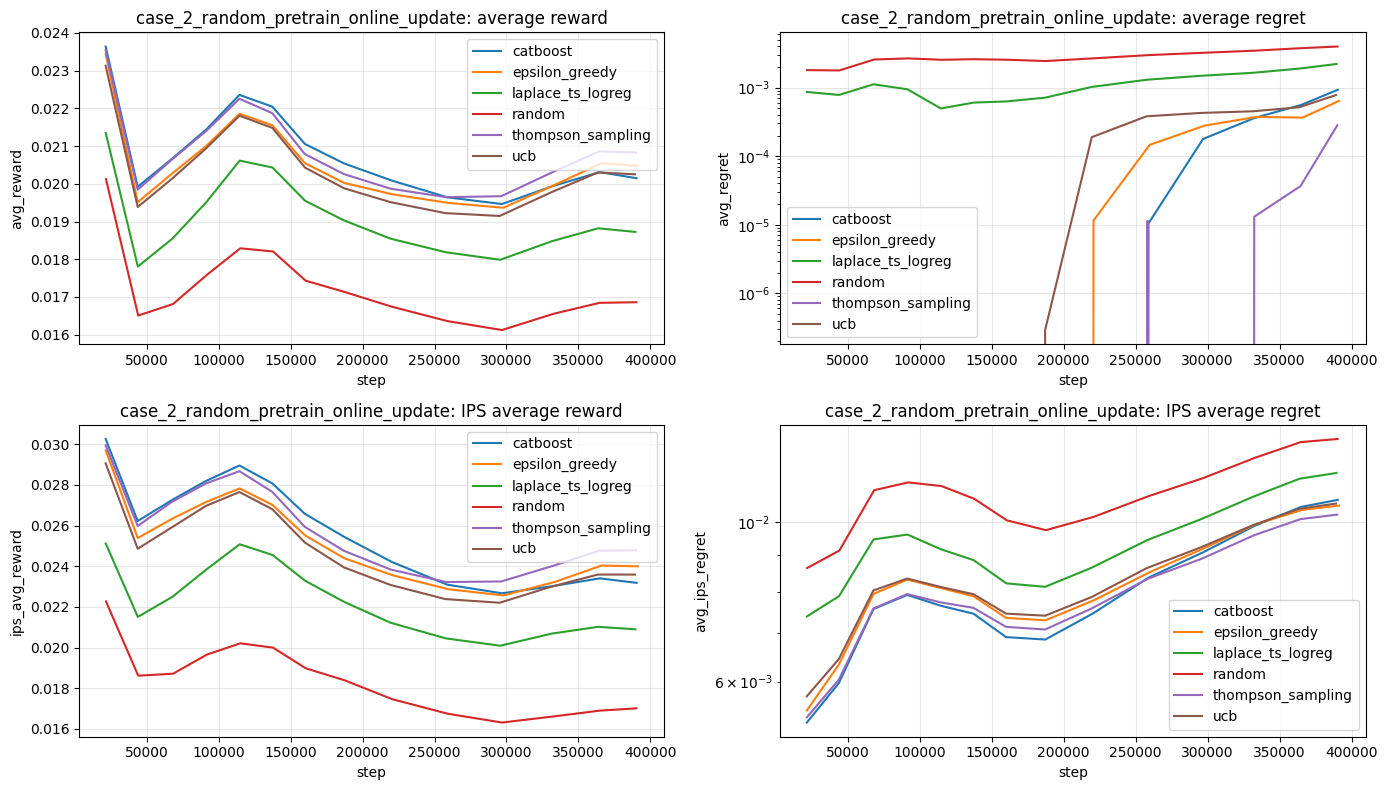

In [15]:
if not history_df.empty:
    for scenario_name, part in history_df.groupby('scenario'):
        fig, axes = plt.subplots(2, 2, figsize=(14, 8))

        for algo, algo_df in part.groupby('algo'):
            max_step = int(algo_df['step'].max()) if len(algo_df) else 0
            stride = max(1, int(round(max_step * 0.05)))  # каждые 5%
            ds = algo_df.iloc[stride::stride] if len(algo_df) > stride else algo_df  # стартуем с 5%

            axes[0, 0].plot(ds['step'], ds['avg_reward'], label=algo)
            axes[0, 1].plot(ds['step'], ds['avg_regret'], label=algo)
            axes[1, 0].plot(ds['step'], ds['ips_avg_reward'], label=algo)
            axes[1, 1].plot(ds['step'], ds['avg_ips_regret'], label=algo)

        axes[0, 0].set_title(f'{scenario_name}: average reward')
        axes[0, 0].set_xlabel('step')
        axes[0, 0].set_ylabel('avg_reward')

        axes[0, 1].set_title(f'{scenario_name}: average regret')
        axes[0, 1].set_xlabel('step')
        axes[0, 1].set_ylabel('avg_regret')
        axes[0, 1].set_yscale('log')

        axes[1, 0].set_title(f'{scenario_name}: IPS average reward')
        axes[1, 0].set_xlabel('step')
        axes[1, 0].set_ylabel('ips_avg_reward')

        axes[1, 1].set_title(f'{scenario_name}: IPS average regret')
        axes[1, 1].set_xlabel('step')
        axes[1, 1].set_ylabel('avg_ips_regret')
        axes[1, 1].set_yscale('log')

        for ax in axes.ravel():
            ax.grid(True, alpha=0.3)
            ax.legend()

        fig.tight_layout()
        plt.show()
else:
    print('History is empty.')

In [16]:
from bandit_benchmark import filter_test_by_train_candidate_coverage
test_same_actions_as_train = filter_test_by_train_candidate_coverage(train_df, test_df)

In [17]:
test_same_actions_as_train

candidates,date,num_candidates,policy,reward,show,features,candidates_list,features_list,propensity
str,datetime[μs],i64,str,f64,i64,str,list[i64],list[f64],f64
"""8761""",2026-02-02 00:00:00,1,"""random""",0.0,8761,"""0\t0\t0\t0\t0\t0\t0\t0\t0\t0\t…",[8761],"[-0.026114, -0.201274, … 1.467983]",1.0
"""7234""",2026-02-02 00:00:00,1,"""random""",0.0,7234,"""0\t0\t0\t0\t0\t0\t0\t0\tnull\t…",[7234],"[-0.026114, -0.201274, … -0.361316]",1.0
"""8761""",2026-02-02 00:00:00,1,"""random""",0.0,8761,"""0\t0\t0\t0\t0\t0\t0\t214.169\t…",[8761],"[-0.026114, -0.201274, … -0.361316]",1.0
"""8761""",2026-02-02 00:00:00,1,"""random""",0.0,8761,"""0\t0\t0\t0\t0\t0\t0\t0\tnull\t…",[8761],"[-0.026114, -0.201274, … -0.361316]",1.0
"""8734""",2026-02-02 00:00:00,1,"""random""",1.0,8734,"""0\t0\t0\t0\t0\t0\t0\t0\tnull\t…",[8734],"[-0.026114, -0.201274, … -0.361316]",1.0
…,…,…,…,…,…,…,…,…,…
"""8761""",2026-02-16 00:00:00,1,"""random""",0.0,8761,"""0\t0\t0\t0\t1000\t1000\t0\t0\t…",[8761],"[-0.026114, -0.201274, … -0.361316]",1.0
"""8761""",2026-02-16 00:00:00,1,"""random""",0.0,8761,"""0\t0\t0\t0\t0\t0\t0\t0\t0\t0.0…",[8761],"[-0.026114, -0.201274, … -0.361316]",1.0
"""8761""",2026-02-16 00:00:00,1,"""random""",0.0,8761,"""0\t0\t0\t0\t0\t0\t0\t0\tnull\t…",[8761],"[-0.026114, -0.201274, … -0.361316]",1.0


In [20]:
env_reward = None
if SIMULATE:
    expected_fn = build_expected_reward_estimator(train_df)
    env_reward = make_simulated_environment(
        proba_predictor=expected_fn,
        stochastic=STOCHASTIC_SIM,
        seed=SEED,
    )

result = run_scenarios(
    train_df=train_df2,
    test_df=test_same_actions_as_train.sample(fraction=0.4, shuffle=True).sort("date"),
    policy_factories=policy_factories,
    scenarios=scenarios,
    env_reward=env_reward,
    show_progress=True,
)

metrics_df = result['metrics']
history_df = result['history']
action_stats_df = result['action_stats']
action_daily_stats_df = result['action_daily_stats']

display(metrics_df)
print('history rows:', len(history_df))
if SIMULATE:
    display(action_stats_df)
    display(action_daily_stats_df)


case_2_random_pretrain_online_update/random:   0%| 

case_2_random_pretrain_online_update/random: train_unique_actions=50


case_2_random_pretrain_online_update/epsilon_greedy

case_2_random_pretrain_online_update/epsilon_greedy: train_unique_actions=50


case_2_random_pretrain_online_update/ucb:   0%| | 0

...

case_2_random_pretrain_online_update/laplace_ts_logreg: train_unique_actions=50


case_2_random_pretrain_online_update/catboost:   0%

case_2_random_pretrain_online_update/catboost: train_unique_actions=50


,impressions_total,impressions_used,total_reward,ctr,ips_weighted_reward,ips_ctr,replay_match_rate,cumulative_regret,avg_regret,cumulative_ips_regret,avg_ips_regret,scenario,algo
0,501802,450762,7087.0,0.015722,8903.0,0.017742,0.898287,1126.688768,0.002500,4384.140091,0.008737,case_2_random_pretrain_online_update,random
1,501802,451825,8300.0,0.018370,11675.0,0.023266,0.900405,54.512126,0.000121,3171.140091,0.006320,case_2_random_pretrain_online_update,epsilon_greedy
2,501802,451606,8232.0,0.018228,11465.0,0.022848,0.899969,104.543186,0.000231,3239.140091,0.006455,case_2_random_pretrain_online_update,ucb
3,501802,451959,8417.0,0.018623,11943.0,0.023800,0.900672,-47.479078,-0.000105,3054.140091,0.006086,case_2_random_pretrain_online_update,thompson_sampling
4,501802,451360,7971.0,0.017660,10799.0,0.021520,0.899478,316.333029,0.000701,3500.140091,0.006975,case_2_random_pretrain_online_update,laplace_ts_logreg
5,501802,452029,8428.0,0.018645,11970.0,0.023854,0.900811,-48.585689,-0.000107,3043.140091,0.006064,case_2_random_pretrain_online_update,catboost


history rows: 2709541


In [30]:
display(metrics_df[["ips_ctr", "avg_ips_regret", "algo"]].sort_values("ips_ctr", ascending=False))

,ips_ctr,avg_ips_regret,algo
5,0.023854,0.006064,catboost
3,0.023800,0.006086,thompson_sampling
1,0.023266,0.006320,epsilon_greedy
2,0.022848,0.006455,ucb
4,0.021520,0.006975,laplace_ts_logreg
0,0.017742,0.008737,random


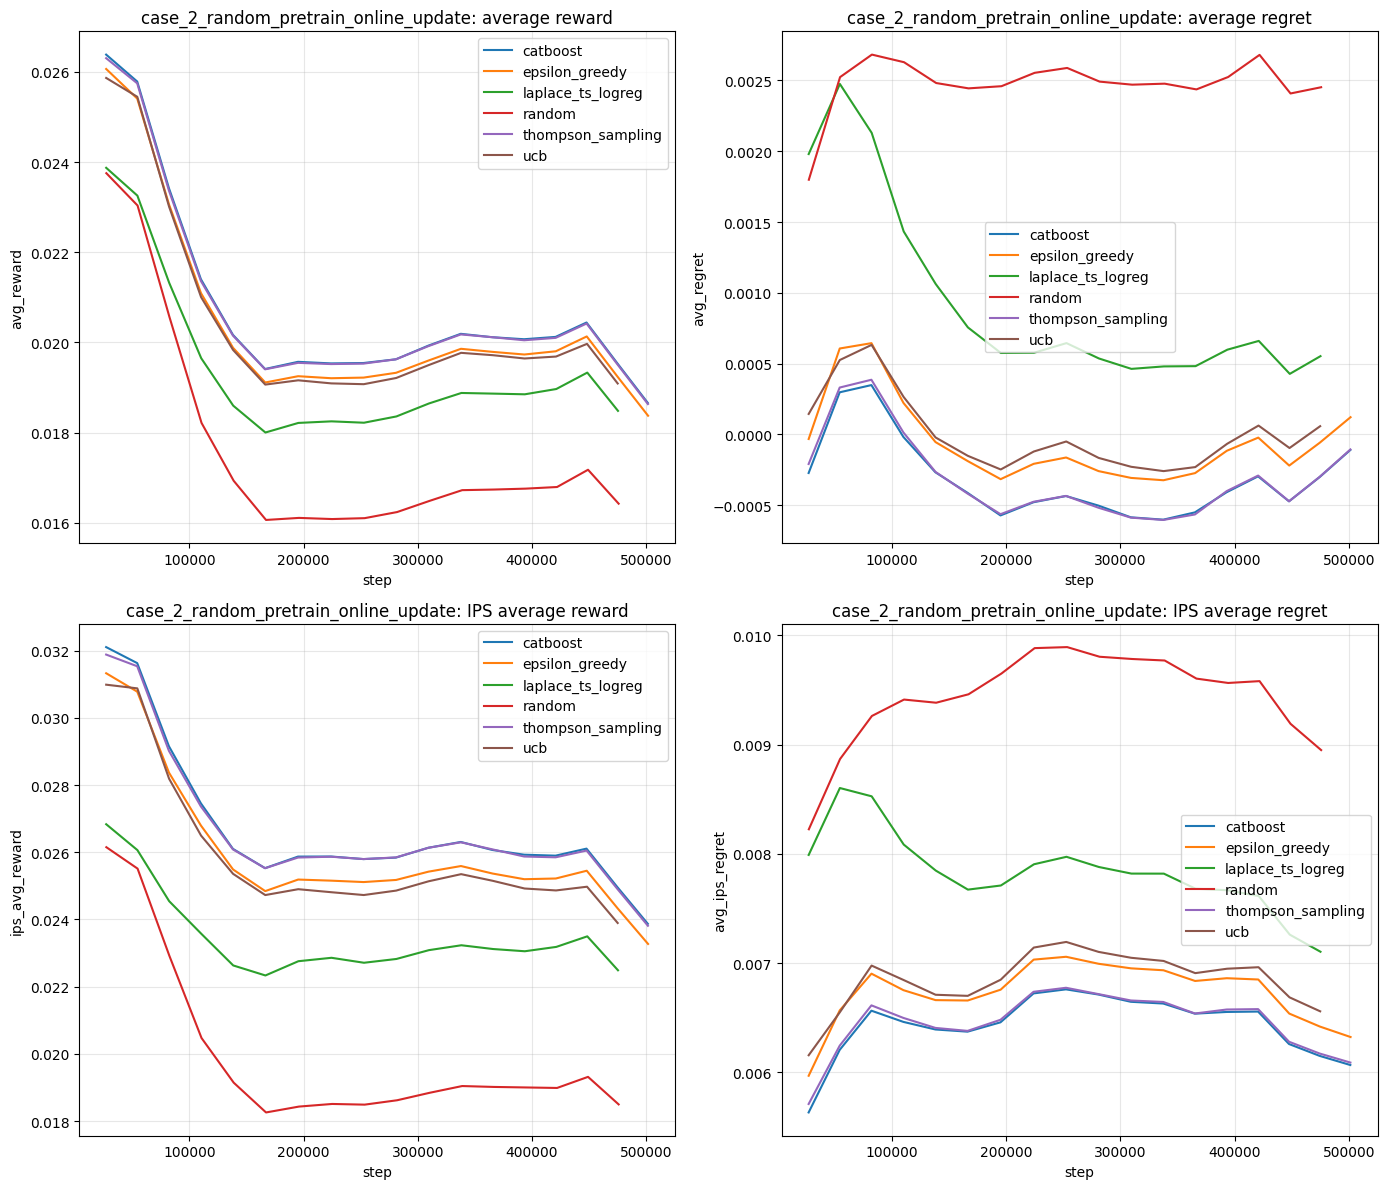

In [24]:
if not history_df.empty:
    for scenario_name, part in history_df.groupby('scenario'):
        fig, axes = plt.subplots(2, 2, figsize=(14, 12))

        for algo, algo_df in part.groupby('algo'):
            max_step = int(algo_df['step'].max()) if len(algo_df) else 0
            stride = max(1, int(round(max_step * 0.05)))  # каждые 5%
            ds = algo_df.iloc[stride::stride] if len(algo_df) > stride else algo_df  # стартуем с 5%

            axes[0, 0].plot(ds['step'], ds['avg_reward'], label=algo)
            axes[0, 1].plot(ds['step'], ds['avg_regret'], label=algo)
            axes[1, 0].plot(ds['step'], ds['ips_avg_reward'], label=algo)
            axes[1, 1].plot(ds['step'], ds['avg_ips_regret'], label=algo)

        axes[0, 0].set_title(f'{scenario_name}: average reward')
        axes[0, 0].set_xlabel('step')
        axes[0, 0].set_ylabel('avg_reward')

        axes[0, 1].set_title(f'{scenario_name}: average regret')
        axes[0, 1].set_xlabel('step')
        axes[0, 1].set_ylabel('avg_regret')
        # axes[0, 1].set_yscale('log')

        axes[1, 0].set_title(f'{scenario_name}: IPS average reward')
        axes[1, 0].set_xlabel('step')
        axes[1, 0].set_ylabel('ips_avg_reward')

        axes[1, 1].set_title(f'{scenario_name}: IPS average regret')
        axes[1, 1].set_xlabel('step')
        axes[1, 1].set_ylabel('avg_ips_regret')
        # axes[1, 1].set_yscale('log')

        for ax in axes.ravel():
            ax.grid(True, alpha=0.3)
            ax.legend()

        fig.tight_layout()
        plt.show()
else:
    print('History is empty.')

## 6) Графики по статистикам action'ов
Показывает динамику общего числа уникальных action'ов и количества новых action'ов по дням/checkpoint'ам.

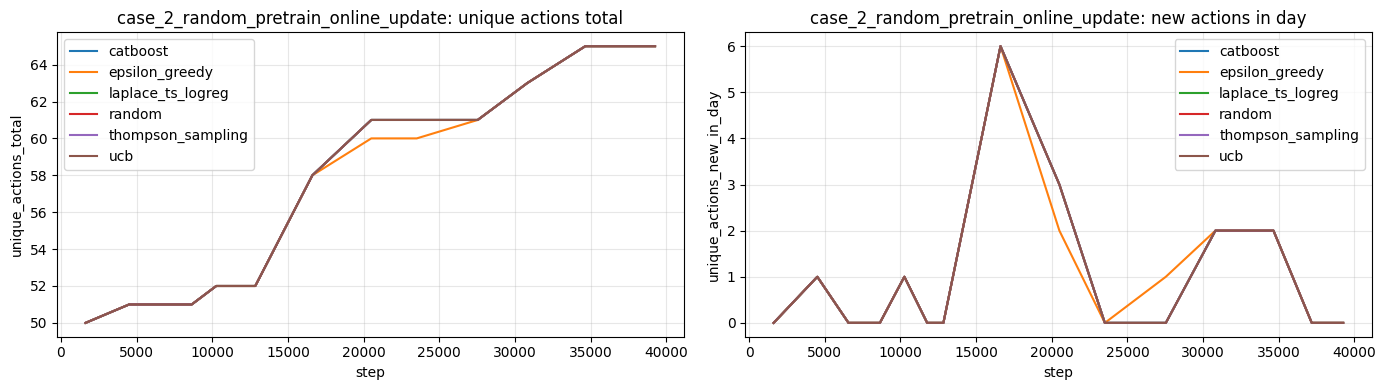

In [10]:
if not action_stats_df.empty:
    for scenario_name, part in action_stats_df.groupby('scenario'):
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        for algo, algo_df in part.groupby('algo'):
            algo_df = algo_df.sort_values('step')
            axes[0].plot(algo_df['step'], algo_df['unique_actions_total'], label=algo)
            axes[1].plot(algo_df['step'], algo_df['unique_actions_new_in_day'], label=algo)

        axes[0].set_title(f"{scenario_name}: unique actions total")
        axes[0].set_xlabel('step')
        axes[0].set_ylabel('unique_actions_total')

        axes[1].set_title(f"{scenario_name}: new actions in day")
        axes[1].set_xlabel('step')
        axes[1].set_ylabel('unique_actions_new_in_day')

        for ax in axes:
            ax.grid(True, alpha=0.3)
            ax.legend()

        fig.tight_layout()
        plt.show()
else:
    print('action_stats_df is empty.')


## 8) Распределение показов по action и дням


/var/folders/2h/f3088zln2y36htvcq0wjvt94_1rc11/T/ipykernel_69395/4204116454.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


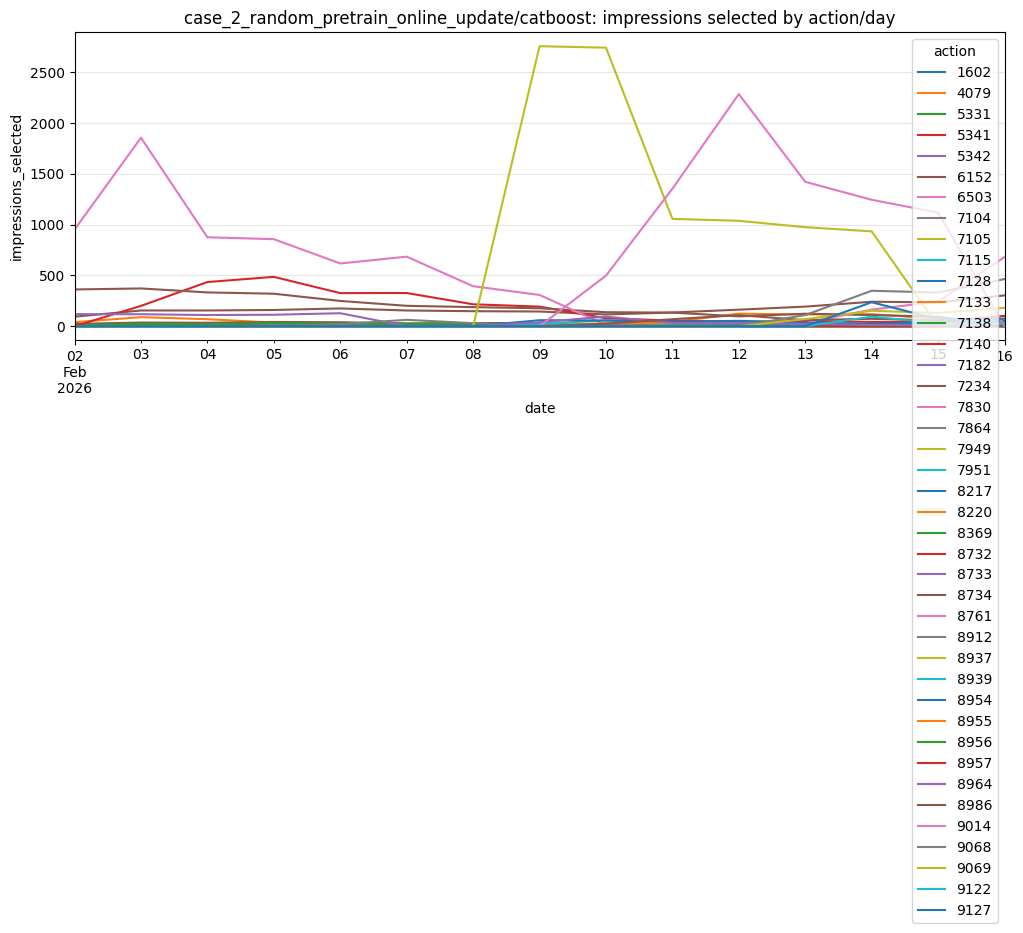

/var/folders/2h/f3088zln2y36htvcq0wjvt94_1rc11/T/ipykernel_69395/4204116454.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


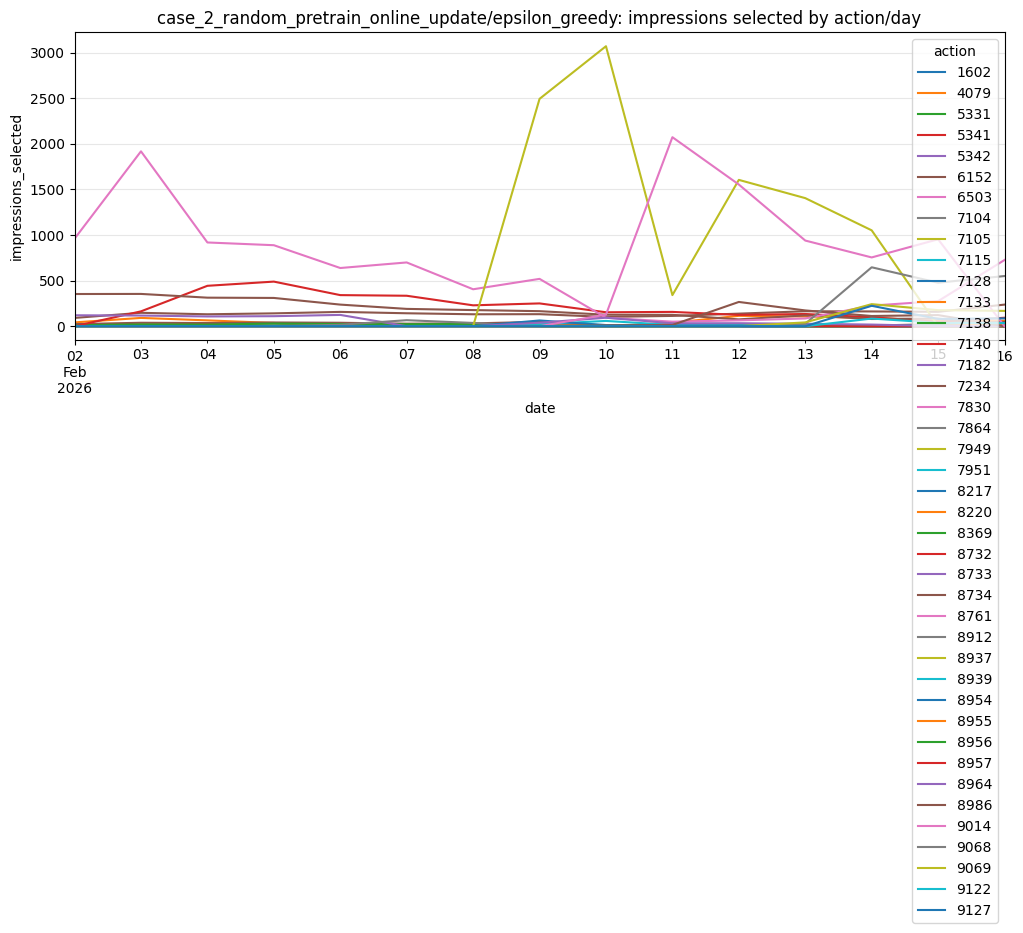

/var/folders/2h/f3088zln2y36htvcq0wjvt94_1rc11/T/ipykernel_69395/4204116454.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


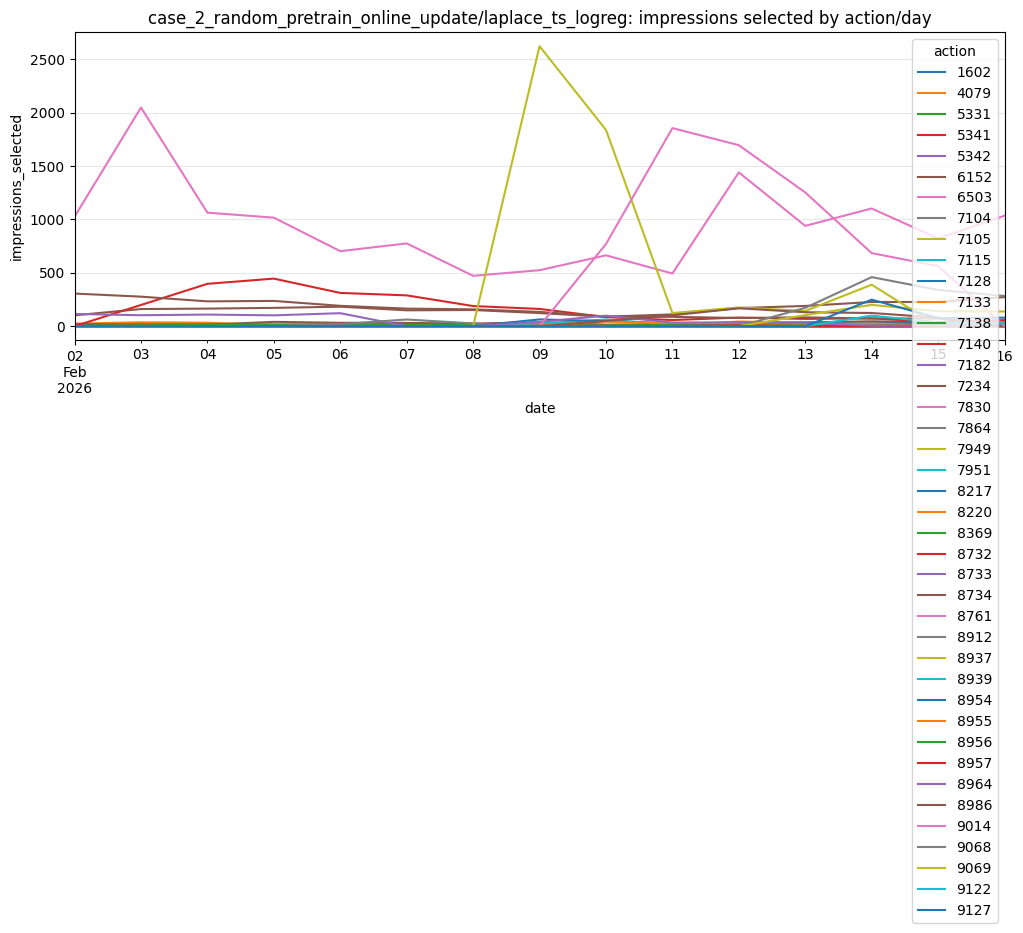

/var/folders/2h/f3088zln2y36htvcq0wjvt94_1rc11/T/ipykernel_69395/4204116454.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


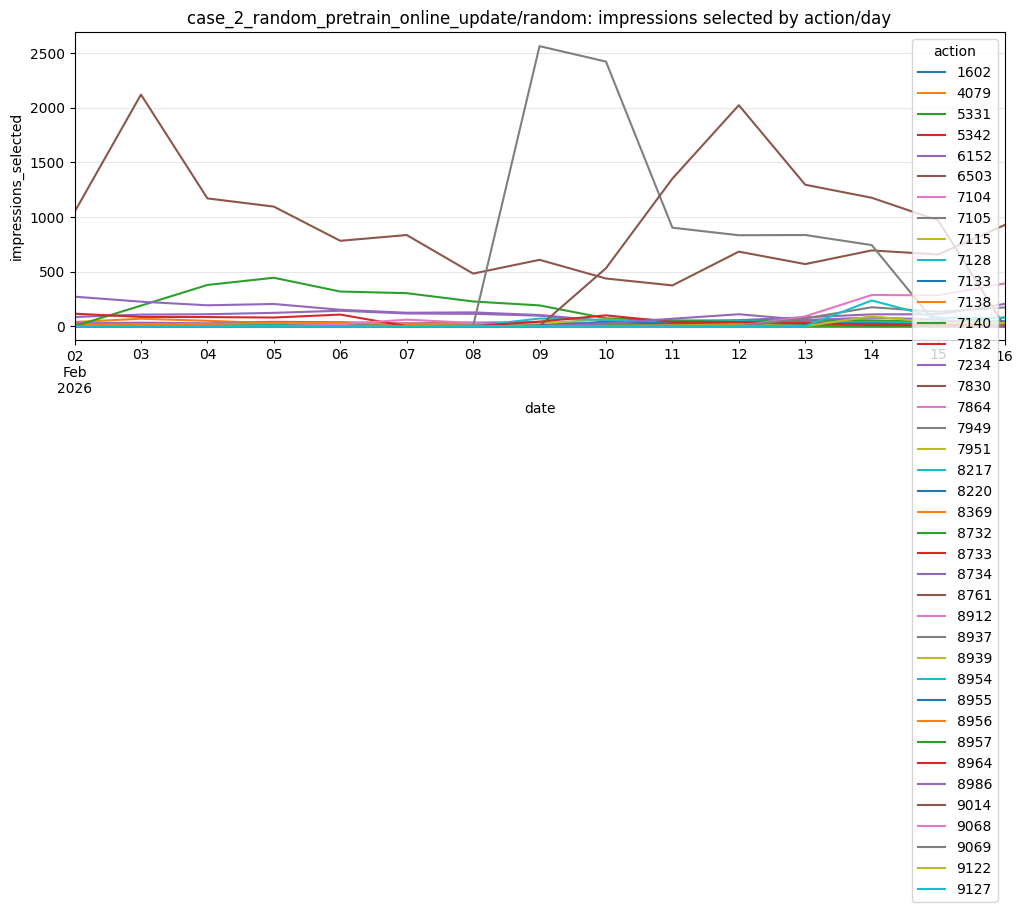

/var/folders/2h/f3088zln2y36htvcq0wjvt94_1rc11/T/ipykernel_69395/4204116454.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


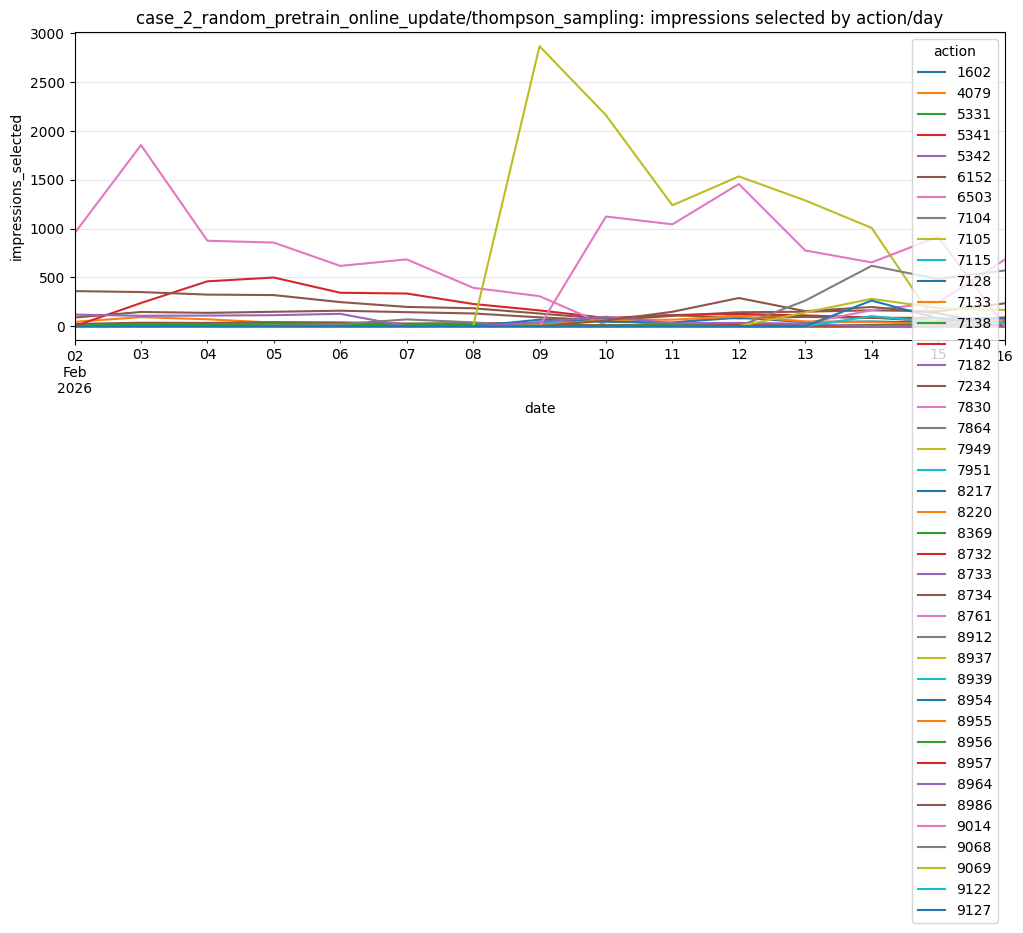

/var/folders/2h/f3088zln2y36htvcq0wjvt94_1rc11/T/ipykernel_69395/4204116454.py:12: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  fig.tight_layout()


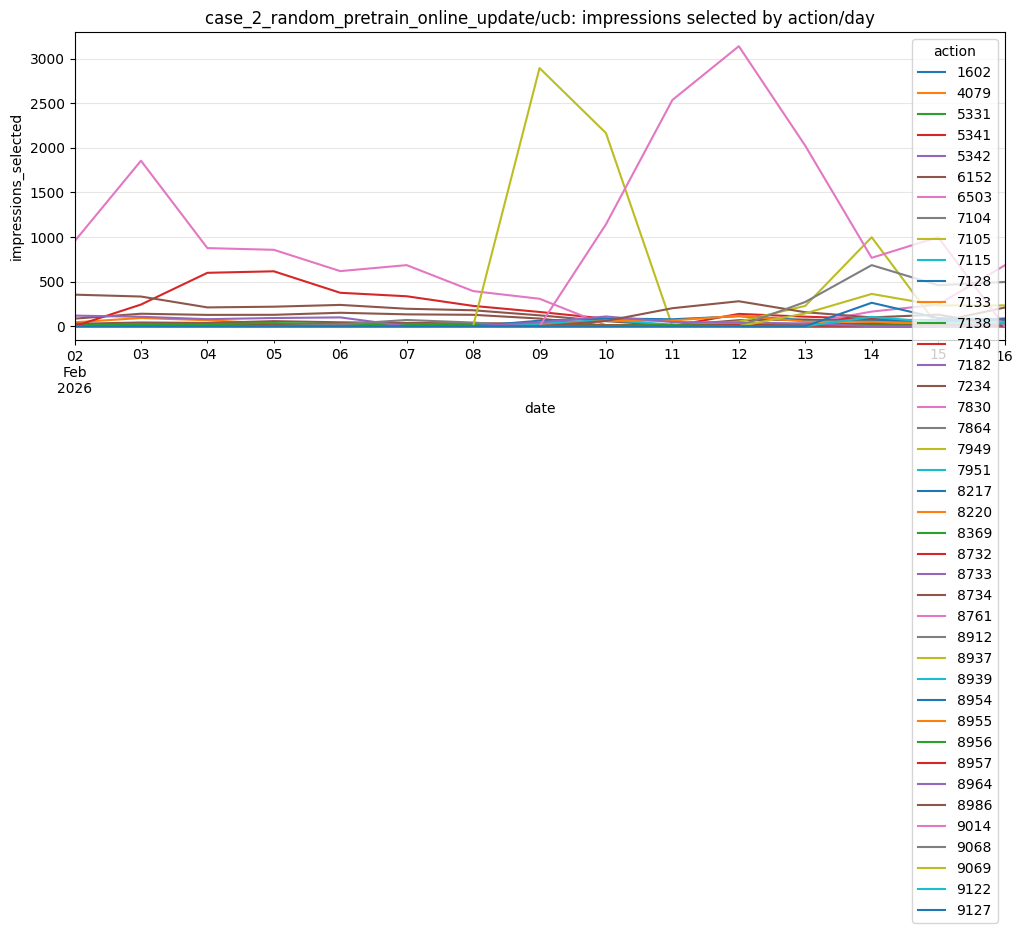

In [11]:
if not action_daily_stats_df.empty:
    for scenario_name, part in action_daily_stats_df.groupby('scenario'):
        for algo_name, algo_df in part.groupby('algo'):
            pivot_cnt = algo_df.pivot_table(index='date', columns='action', values='impressions_selected', aggfunc='sum').fillna(0)

            fig, ax = plt.subplots(figsize=(12, 4))
            pivot_cnt.sort_index().plot(ax=ax)
            ax.set_title(f'{scenario_name}/{algo_name}: impressions selected by action/day')
            ax.set_xlabel('date')
            ax.set_ylabel('impressions_selected')
            ax.grid(True, alpha=0.3)
            fig.tight_layout()
            plt.show()
else:
    print('action_daily_stats_df is empty.')


## 9) Сохранение артефактов

In [ ]:
OUT_DIR = ROOT / 'artifacts'
OUT_DIR.mkdir(parents=True, exist_ok=True)

metrics_path = OUT_DIR / 'metrics.csv'
history_path = OUT_DIR / 'history.csv'
action_stats_path = OUT_DIR / 'action_stats.csv'
action_daily_stats_path = OUT_DIR / 'action_daily_stats.csv'

metrics_df.to_csv(metrics_path, index=False)
history_df.to_csv(history_path, index=False)
action_stats_df.to_csv(action_stats_path, index=False)
action_daily_stats_df.to_csv(action_daily_stats_path, index=False)

print('saved metrics:', metrics_path)
print('saved history:', history_path)
print('saved action stats:', action_stats_path)
print('saved action daily stats:', action_daily_stats_path)
